# CMP 262: Project 1 - Part 3 Data Analysis & Visualization
**Author:** Xavier Malin  
**Date:** October 4, 2026  
**Dataset:** Non-Majors Survey Results - Fall 2024  
**Target Audience:** CCM IT Department

## Project Overview & Objectives
This notebook analyzes survey responses from non-computer science majors at County College of Morris (CCM) during Fall 2024. The objective is to examine student enrollment motivations, pre-college outreach exposure, interest levels, and specific course preferences to deliver data-driven recruiting and messaging recommendations for the CCM IT Department.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("project/cleaned_non_majors_fall_2024.csv")
df.head()

,timestamp,course_enrolled,What motivated you to seek a computing class at CCM? [It’s a required class for the degree I’m seeking],What motivated you to seek a computing class at CCM? [To keep current in computing skills],What motivated you to seek a computing class at CCM? [Career Advancement],What motivated you to seek a computing class at CCM? [Career Change],What motivated you to seek a computing class at CCM? [Professional Development],What motivated you to seek a computing class at CCM? [Job Displacement],What motivated you to seek a computing class at CCM? [Relocation],What motivated you to seek a computing class at CCM? [IT Industry Certifications],...,"If you answered that you were interested in taking more computing classes, which ones interest you most? [Data Analytics]","If you answered that you were interested in taking more computing classes, which ones interest you most? [Machine Learning/Artificial Intelligence]","If you answered that you were interested in taking more computing classes, which ones interest you most? [Computer Programming]","If you answered that you were interested in taking more computing classes, which ones interest you most? [Game Design]","If you answered that you were interested in taking more computing classes, which ones interest you most? [Hardware Installation & Repair]",gender,race_ethnicity,age_group,degree_category,race_ethnicity_clean
0,2024/09/10 10:47:35 AM AST,CMP 126 Computer Technology and Applications,No,Yes,Yes,Yes,Yes,No,No,No,...,No,No,No,No,No,Prefer not to say,Hispanic or Latino;Black/African American;Whit...,19-20,Liberal Arts,Multi-Racial
1,2024/09/10 11:00:05 AM AST,CMP 126 Computer Technology and Applications,Yes,Yes,Yes,No,Yes,Yes,No,No,...,Yes,Yes,Yes,No,No,Woman,Hispanic or Latino,19-20,Social Sciences,Hispanic or Latino
2,2024/09/10 11:02:51 AM AST,CMP 126 Computer Technology and Applications,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,...,No,Yes,Yes,Yes,Yes,Man,Choose not to reply,18 and younger,Arts & Communication,Choose not to reply
3,2024/09/10 11:05:25 AM AST,CMP 126 Computer Technology and Applications,No,Yes,No,No,No,No,No,No,...,Yes,No,No,Yes,No,Man,Hispanic or Latino,19-20,Other Applied Sciences/Humanities,Hispanic or Latino
4,2024/09/10 8:37:36 PM AST,CMP 101 Computer Information Literacy,Yes,Yes,Yes,No,Yes,No,No,No,...,No,No,No,No,No,Woman,White/Caucasian,19-20,Arts & Communication,White/Caucasian


In [2]:
print(df.columns.tolist())

['timestamp', 'course_enrolled', 'What motivated you to seek a computing class at CCM? [It’s a required class for the degree I’m seeking]', 'What motivated you to seek a computing class at CCM? [To keep current in computing skills]', 'What motivated you to seek a computing class at CCM? [Career Advancement]', 'What motivated you to seek a computing class at CCM? [Career Change]', 'What motivated you to seek a computing class at CCM? [Professional Development]', 'What motivated you to seek a computing class at CCM? [Job Displacement]', 'What motivated you to seek a computing class at CCM? [Relocation]', 'What motivated you to seek a computing class at CCM? [IT Industry Certifications]', 'What motivated you to seek a computing class at CCM? [Financial]', 'What motivated you to seek a computing class at CCM? [Personal Enrichment]', 'What motivated you to seek a computing class at CCM? [Curiosity]', 'Prior to applying to college, did you participate in any of the following events or activi

---
## Question 1: Top Recruitment Motivation Drivers
**Research Question:** Which top recruitment reasons drive non-major enrollment into computing courses at CCM?

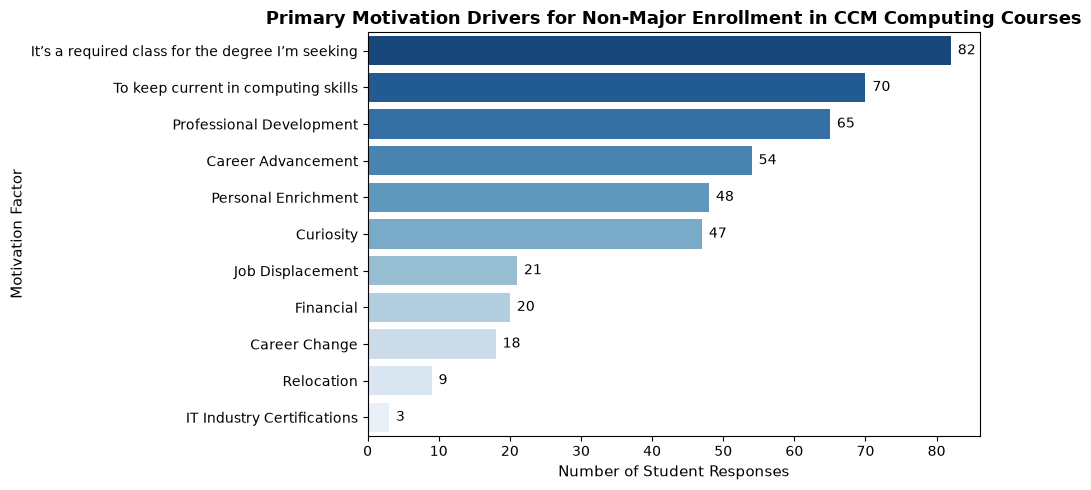

In [7]:
# Filter dataframe columns related to student enrollment motivation
mot_cols = [c for c in df.columns if 'What motivated you to seek a computing class at CCM?' in c]

# Calculate actual selections by ignoring unselected filler values
unselected_values = ['', 'nan', 'none', 'no', 'false', '0', 'not selected']
counts_dict = {}

for col in mot_cols:
    label = col.split('[')[1].replace(']', '').strip() if '[' in col else col
    s_clean = df[col].astype(str).str.strip().str.lower()
    counts_dict[label] = s_clean[~s_clean.isin(unselected_values)].count()

mot_counts = pd.Series(counts_dict).sort_values(ascending=False)

# Plot primary motivation drivers using Seaborn horizontal bar plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=mot_counts.values, 
    y=mot_counts.index, 
    hue=mot_counts.index, 
    palette="Blues_r", 
    legend=False
)

plt.title("Primary Motivation Drivers for Non-Major Enrollment in CCM Computing Courses", fontsize=13, fontweight='bold')
plt.xlabel("Number of Student Responses", fontsize=11)
plt.ylabel("Motivation Factor", fontsize=11)

# Annotate each bar with exact response counts
for p in ax.patches:
    if p.get_width() > 0:
        ax.annotate(f'{int(p.get_width())}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

### Analysis & Findings (Q1)
* **Key Finding:** Degree requirement fulfillment, personal enrichment, and career advancement represent the primary motivations driving non-majors to take computing classes at CCM.
* **Recruiting & Messaging Strategy:** Frame marketing campaigns around career versatility and skill enhancement. Highlight how introductory computing skills complement diverse non-CS majors (such as Business, Humanities, and Fine Arts) in the job market.

---
## Question 2: Non-Major Interest in Future Computing Courses
**Research Question:** How interested are non-majors in taking another computing course at CCM?

C:\Users\xavie\AppData\Local\Temp\ipykernel_18088\2762722141.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=interest_counts.index, y=interest_counts.values, palette="crest")


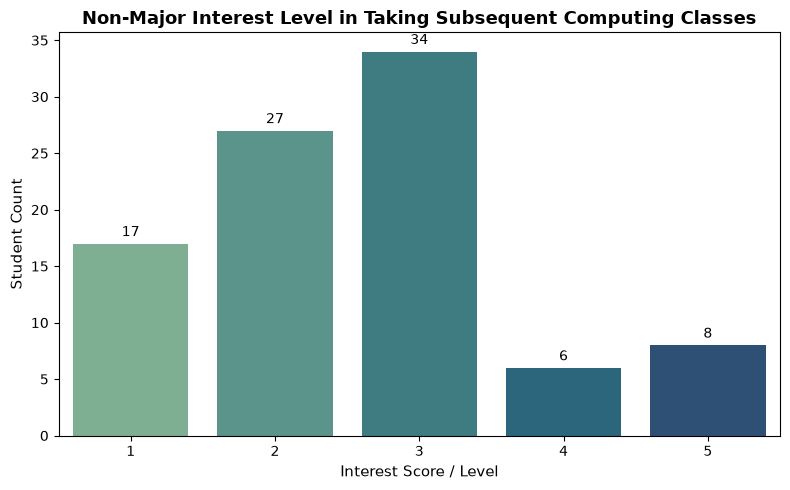

In [4]:
interest_counts = df['computing_interest_score'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=interest_counts.index, y=interest_counts.values, palette="crest")
plt.title("Non-Major Interest Level in Taking Subsequent Computing Classes", fontsize=13, fontweight='bold')
plt.xlabel("Interest Score / Level", fontsize=11)
plt.ylabel("Student Count", fontsize=11)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

### Analysis & Findings (Q2)
* **Key Finding:** Survey results show a substantial latent interest among non-majors in pursuing additional computing coursework beyond their initial course enrollment.
* **Recruiting & Messaging Strategy:** Send targeted follow-up communications (via Canvas announcements or direct email) to currently enrolled non-majors right before registration windows, showcasing flexible or asynchronous elective options.

---
## Question 3: Common Pre-College Outreach Activities
**Research Question:** What are the most common pre-college events and outreach activities among non-majors prior to attending CCM?

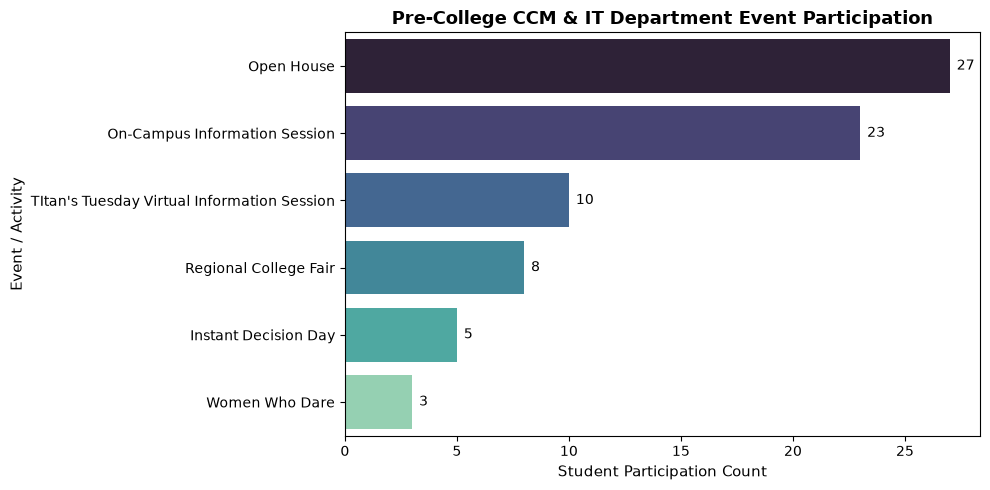

In [8]:
# Identify columns tracking pre-college event participation
pre_cols = [c for c in df.columns if 'Prior to applying to college, did you participate' in c]

unselected_values = ['', 'nan', 'none', 'no', 'false', '0', 'not selected']
pre_dict = {}

for col in pre_cols:
    label = col.split('[')[1].replace(']', '').strip() if '[' in col else col
    s_clean = df[col].astype(str).str.strip().str.lower()
    pre_dict[label] = s_clean[~s_clean.isin(unselected_values)].count()

pre_counts = pd.Series(pre_dict).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=pre_counts.values, 
    y=pre_counts.index, 
    hue=pre_counts.index, 
    palette="mako", 
    legend=False
)

plt.title("Pre-College CCM & IT Department Event Participation", fontsize=13, fontweight='bold')
plt.xlabel("Student Participation Count", fontsize=11)
plt.ylabel("Event / Activity", fontsize=11)

for p in ax.patches:
    if p.get_width() > 0:
        ax.annotate(f'{int(p.get_width())}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

### Analysis & Findings (Q3)
* **Key Finding:** Broad-appeal campus outreach events—such as Open House programs and High School Information Sessions—yield significantly higher participation than specialized niche activities.
* **Recruiting & Messaging Strategy:** Direct outreach resources toward high-volume, general college events by embedding interactive IT demonstrations and student showcases, rather than relying solely on standalone departmental events.

---
## Question 4: Course Specific Interest
**Research Question:** Which specific computing courses generate the highest interest among non-majors?

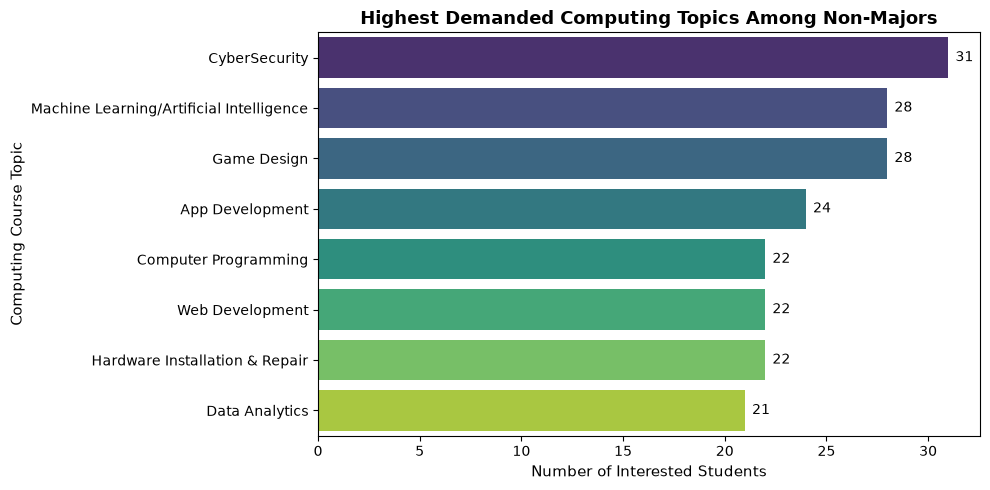

In [9]:
# Extract survey columns for course topic preferences
course_cols = [c for c in df.columns if 'which ones interest you most?' in c]

unselected_values = ['', 'nan', 'none', 'no', 'false', '0', 'not selected']
course_dict = {}

for col in course_cols:
    label = col.split('[')[1].replace(']', '').strip() if '[' in col else col
    s_clean = df[col].astype(str).str.strip().str.lower()
    course_dict[label] = s_clean[~s_clean.isin(unselected_values)].count()

course_counts = pd.Series(course_dict).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=course_counts.values, 
    y=course_counts.index, 
    hue=course_counts.index, 
    palette="viridis", 
    legend=False
)

plt.title("Highest Demanded Computing Topics Among Non-Majors", fontsize=13, fontweight='bold')
plt.xlabel("Number of Interested Students", fontsize=11)
plt.ylabel("Computing Course Topic", fontsize=11)

for p in ax.patches:
    if p.get_width() > 0:
        ax.annotate(f'{int(p.get_width())}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

### Analysis & Findings (Q4)
* **Key Finding:** Web Development, Computer Programming, and Data Analytics command the highest student demand, outperforming traditional hardware or infrastructure topics.
* **Recruiting & Messaging Strategy:** Highlight practical Web Development and introductory programming modules on promotional materials aimed at non-CS majors to maximize registration volume.

---
## Strategic Summary & Recommendations for CCM IT Department
1. **Capitalize on General Admissions Events:** Integrate IT program showcases into campus-wide Open Houses and High School Visit Days where student exposure is highest.
2. **Promote Applied Skillsets:** Focus messaging on Web Development, Python, and Data Analytics, emphasizing their immediate utility across non-tech career fields.
3. **Engage Current Non-Major Enrollees:** Retarget students already enrolled in introductory computing classes near course registration dates to encourage elective pathway continuation.